<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/HW01MFWK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Caso de Estudio: Parque Fotovoltaico "Atacama Sun"**
**Empresa:** Andes Renewable Energy S.A.

**Ubicación:** Región de Atacama, Chile

### **Datos del Proyecto**

- **Inversión inicial ($I_0$):** US\$100 millones para una planta fotovoltaica de 120 MW.

- **Tasa de descuento ( r ):** 8%

- **Tasa de crecimiento de flujos ( g ):** 2% anual

- **Flujo de caja libre esperado del año 1 ( FCF1 ):** El modelo del departamento de ingeniería proyecta un flujo neto de US\$7 millones en el primer año.

La fórmula simplificada de *Valor Actual Neto (VAN)* a perpetuidad es:

$$VAN = -I_0 + \frac{FCF_1}{r - g}$$



En la evaluación de proyectos de infraestructura y energía, basarse exclusivamente en un "escenario promedio" genera una falsa sensación de seguridad. El verdadero riesgo de un proyecto no está en su valor esperado, sino en la variabilidad de sus resultados y en su exposición a eventos de cola (escenarios adversos de baja probabilidad pero alto impacto). Para modelar esta incertidumbre, se construyó una simulación de Monte Carlo asumiendo que el *flujo de caja libre del año 1 ($FCF_1$)* sigue una Distribución Normal con media $\mu = \$7.0\text{M}$ y desviación estándar $\sigma = \$1.5\text{M}$.


## **Código Base**

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# REEMPLAZA ESTA SEMILLA PARA REPRODUCIBILIDAD
np.random.seed(4126)    # Usa los 4 últimos dígitos de tu Rut sin el dígito verificador

In [ ]:
# PARÁMETROS
n_sims = 10000             # Número de simulaciones
inversion_inicial = 100.0  # Inversión en planta 120 MW en el Norte de Chile
r = 0.08                   # Tasa de descuento
g = 0.02                   # Tasa de crecimiento de flujo de caja

In [ ]:
# 1. SIMULACIÓN BASE
fcf_1 = np.random.normal(loc=7.0, scale=1.5, size=n_sims)  # Flujo de caja libre con media = US$7.0M y desviación estándar = US$1.5M

# 2. CÁLCULO DEL VALOR ACTUAL NETO (VAN)
van_simulados = -inversion_inicial + (fcf_1 / (r - g))

# 3. MÉTRICAS CLAVE
media = np.mean(van_simulados)
mediana = np.median(van_simulados)
p5 = np.percentile(van_simulados, 5)     # VaR 5% (Peor 5% de los casos)
p95 = np.percentile(van_simulados, 95)   # Escenario Optimista
desv_est = np.std(van_simulados, ddof=1) # Desviación estándar
prob_perder = np.mean(van_simulados < 0) * 100

print(f"--- PROYECTO SOLAR ATACAMA (SIMULACIÓN BASE NORMAL) ---")
print(f"VAN Medio: ${media:.2f}M USD")
print(f"VAN Mediano: ${mediana:.2f}M USD")
print(f"Percentil 5 (P5 / VaR 5%): ${p5:.2f}M USD")
print(f"Percentil 95 (P95): ${p95:.2f}M USD")
print(f"VAN Desviación estándar: ${desv_est:.2f}M USD")
print(f"Probabilidad de Destruir Valor (VPN < 0): {prob_perder:.1f}%")

--- PROYECTO SOLAR ATACAMA (SIMULACIÓN BASE NORMAL) ---
VAN Medio: $16.39M USD
VAN Mediano: $16.27M USD
Percentil 5 (P5 / VaR 5%): $-25.41M USD
Percentil 95 (P95): $57.54M USD
VAN Desviación estándar: $25.24M USD
Probabilidad de Destruir Valor (VPN < 0): 25.6%


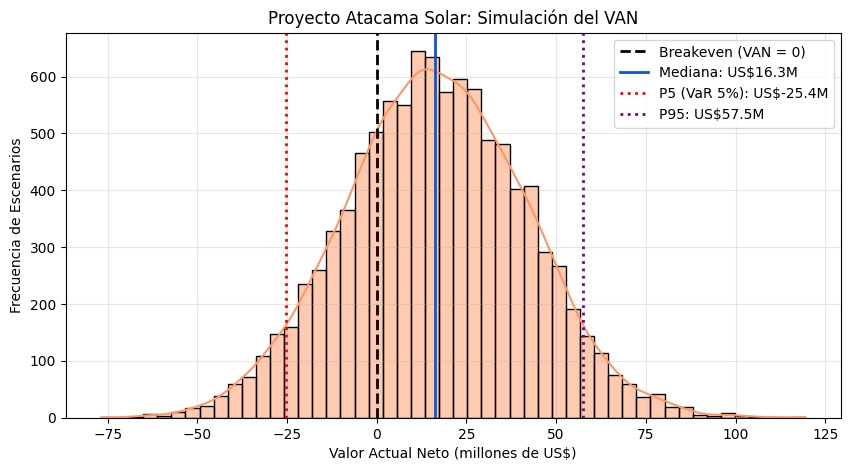

In [ ]:
# 4. VISUALIZACIÓN DE RESULTADOS
plt.figure(figsize=(10, 5))
sns.histplot(van_simulados, kde=True, bins=50, color='#FF9763')

# Líneas de referencia
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Breakeven (VAN = 0)')
plt.axvline(mediana, color='#0F55D1', linestyle='-', linewidth=2, label=f'Mediana: US${mediana:.1f}M')
plt.axvline(p5, color='red', linestyle=':', linewidth=2, label=f'P5 (VaR 5%): US${p5:.1f}M')
plt.axvline(p95, color='purple', linestyle=':', linewidth=2, label=f'P95: US${p95:.1f}M')

plt.title('Proyecto Atacama Solar: Simulación del VAN')
plt.xlabel('Valor Actual Neto (millones de US$)')
plt.ylabel('Frecuencia de Escenarios')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Antes de responder las preguntas 2 a 7, cambia la semilla usando los 4 últimos dígitos de tu Rut sin el dígito verificador:**

## **Pregunta 1**

Utilizando la propiedad de linealidad del valor esperado $E[a + bX] = a + bE[X]$, calcula el valor esperado del VAN, asumiendo que el $FCF_1 \sim N(\mu=7.0, \sigma=1.5)$. Compara este valor promedio del VAN obtenido en la simulación.

**Solución:**

$E(VAN)=-I_0+\frac{E(FC_1)}{r-g}=-100+\frac{7}{0.08-0.02}=-100+116.67=\text{US\$16.67 millones}$

El valor promedio VAN obtenido a través de la simulación es 16.39 millones de dólares, por lo que hay una pequeña diferencia debido a la variabilidad muestral del generador pseudoaleatorio.

## **Pregunta 2**

Aplicando la propiedad de la varianza para transformaciones lineales $Var(a + bX) = b^2 Var(X)$, determina analíticamente la varianza y la desviación estándar del VAN, asumiendo que el  $FCF_1 \sim N(\mu=7.0, \sigma=1.5)$. Compara la desviación estándar con la obtenida en las simulaciones (5 puntos)

## **Pregunta 3**

A partir de la Media ($\mu_{VAN}$) y la Desviación Estándar ($\sigma_{VAN}$) teóricas obtenidas en las *preguntas 1 y 2*. Calcula con Python la probabilidad teórica exacta de que el proyecto destruya valor ($VAN < 0$). Compara este valor con el obtenido a través de las simulaciones. Escribe la función de Python utilizada en el siguiente espacio (10 puntos)

## **Pregunta 4**

En el contexto del mercado eléctrico chileno (congestión en transmisión, precios marginales cero a determinadas horas y curtailment), ¿cuáles son las principales deficiencias de asumir que el flujo de caja ($FCF_1$) tenga una *distribución normal*? Argumenta tu respuesta desde el punto de vista financiero y operativo en un máximo de 10 líneas (10 puntos)

## **Pregunta 5**

Simula el $FCF_1$ utilizando una *distribución log-normal* que mantenga la media objetivo ($\mu$) en US\$ 7 millones y la desviación estándar ($\sigma$) en US\$ 1.5 millones.  Para trabajar con la función `np.random.lognormal(mean, sigma, size)` en Python debes transformar la media y la desviación estándar del espacio lineal al espacio logarítmico ($\mu_{log}$ y $\sigma_{log}$) mediante las siguientes fórmulas:

$$\sigma_{log} = \sqrt{\ln\left(1 + \left(\frac{\sigma}{\mu}\right)^2\right)}$$

$$\mu_{log} = \ln(\mu) - \frac{\sigma_{log}^2}{2}$$



(a) ¿Cuál es el Value at Risk al 5% ($VaR_{5\%}$ / Percentil 5) y la probabilidad de pérdida ($VAN < 0$) bajo la distribución log-normal? Compáralos con los resultados del modelo Normal de la simulación base (Especifica los valores de $\sigma_{log}$ y $\mu_{log}$ y la(s) línea(s) de código que cambiaste en tu respuesta) (10 puntos).


(b) Si la política de riesgos de la empresa establece un límite de tolerancia donde el $VaR_{5\%}$ no puede superar las pérdidas de $US\$ 30.0$ millones, ¿se aprueba o se rechaza el proyecto bajo este modelo de colas pesadas? Justifica en un máximo de 5 líneas (10 puntos)

## **Pregunta 6**

Para mitigar el riesgo de vertimiento de energía durante las horas solares, el equipo de ingeniería propone instalar un sistema de baterías de almacenamiento (BESS). Esta tecnología requiere aumentar la inversión inicial en US\$ 15 millones ($I_0 = \text{US\$ 115 millones}$), pero cambia drásticamente la distribución del flujo de caja del primer año ($FCF_1$) al garantizar un piso de generación. El equipo de operaciones define la nueva incertidumbre del $FCF_1$ mediante una *distribución triangular* con los siguientes tres parámetros:

- **Mínimo ($a$):** US$ 5.0 millones (piso garantizado por la capacidad de descarga de la batería en horas punta).  

- **Moda ($c$):** US$ 7.5 millones (Incremento en ventas al desplazar energía de costo cero a horas de mayor precio).  

- **Máximo ($b$):** US$ 10.0 millones (Capacidad máxima de captura y venta de energía del sistema).

(a) Simula el $FCF_1$ con la distribución triangular `np.random.triangular(left=5, mode=7.5, right=11, size=10000)`. Calcula el $VaR_{5\%}$ (Percentil 5) y la $Prob(VAN<0)$, considerando la nueva inversión inicial de US$ 115 millones (10 puntos)

(b) Compara estos resultados con la situación sin baterías usando la distribución log-normal *(Pregunta 5)*. ¿Qué decisión recomiendas tomar? Evalúa en tu respuesta la compensación entre una mayor inversión inicial y la mejora en la certeza operativa del proyecto (10 puntos)

## **Pregunta 7**

Asume que el horizonte de evaluación corresponde a la vida útil operativa de los activos, $T=30$, y utiliza la fórmula para una anualidad creciente:

$$VAN=-I_0+\frac{FCF_1}{r-g}\times \left[1-\left(\frac{1+g}{1+r}\right)^T\right]$$


(a) Bajo el supuesto del modelo que asume que $I_0=100$ y $FCF_1 \sim N(\mu=7, \sigma=1.5)$), calcula la nueva media ($\mu_{VAN, 30}$) y desviación estándar ($\sigma_{VAN, 30}$) para $T=30$ (10 puntos)  

(b) Determina la probabilidad teórica exacta de que el proyecto destruya valor ($VAN < 0$) (5 puntos)  

(c) Compara los resultados con la perpetuidad (Pregunta 3) y explica cómo impacta a la distribución del $VAN$ acotar el horizonte de evaluación a la vida útil real de la planta (10 puntos)